In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ========= 参数区 =========
csv1_path = "../../CSV/aglu/agludata17.csv"   
csv2_path = "../../CSV/aglu/region_area.csv"  
df_a = pd.read_csv(csv1_path)
df_b = pd.read_csv(csv2_path)

In [7]:
regions = [
    "JPN","USA","CHN","IND","BRA","CAN","CIS",
    "XAF","XME","XNF","XSA","XSE","XOC",
    "XLM","XE25","XER","TUR"
]
regions = sorted(regions)
years = list(range(2010, 2101, 10))   # 2010,2020,...,2100
years.insert(0, 2005)
sce = "SSP2_BaU_NoCC"

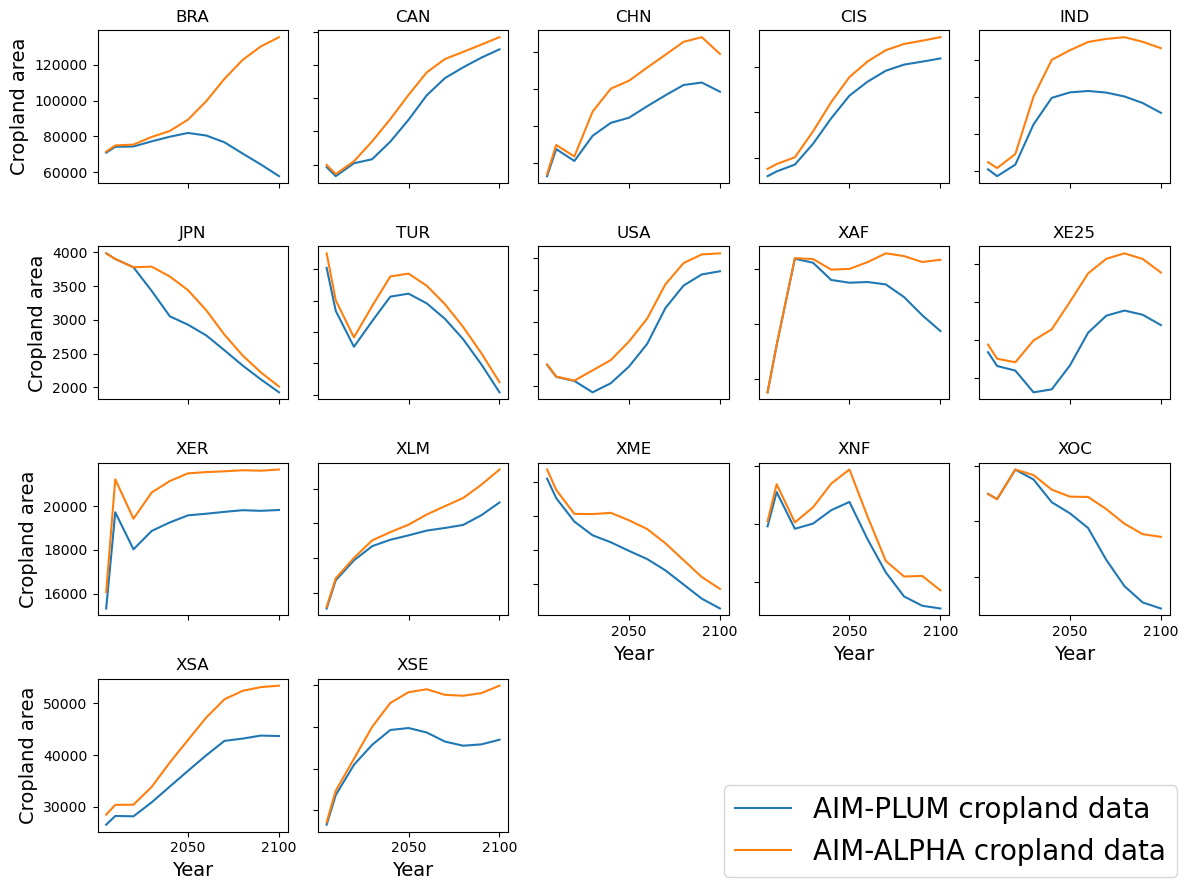

In [8]:
def preprocess(df, regions, years):
    df = df.copy()
    df["year"] = df["year"].astype(int)

    df = df[
        (df["type"] == "CL") &
        (df["region"].isin(regions)) &
        (df["year"].isin(years))
    ]
    return df

df_b = preprocess(df_b, regions, years)
df_a = df_a.copy()
df_a["year"] = df_a["year"].astype(int)

# 只保留需要的 region / year / scenario
df_a = df_a[
    (df_a["region"].isin(regions)) &
    (df_a["year"].isin(years)) &
    (df_a["scenario"] == sce)
]

# --- 拆分 CL 和 CROP_FLW ---
df_cl = df_a[df_a["type"] == "CL"].copy()
df_flow = df_a[df_a["type"] == "CROP_FLW"].copy()

# 只保留必要列，避免重复
df_flow = df_flow[["region", "year", "value"]].rename(
    columns={"value": "CROP_FLW"}
)

# --- 按 region + year 合并 ---
df_cl = df_cl.merge(
    df_flow,
    on=["region", "year"],
    how="left"
)

# --- 做减法 ---
df_cl["value"] = df_cl["value"] - df_cl["CROP_FLW"].fillna(0)

# 如果后面只需要修正后的 CL
df_a = df_cl

# ========= 3. 子图设置 =========
ncols = 5
nrows = 4
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 9), sharex=True)
axes = axes.flatten()
n = len(regions)

# ========= 4. 每个 region 画一张对比图 =========
for i, region in enumerate(regions):
    ax = axes[i]

    sub_a = df_a[df_a["region"] == region].sort_values("year")
    sub_b = df_b[df_b["region"] == region].sort_values("year")
    ax.plot(sub_b["year"], sub_b["value"], label="AIM-PLUM cropland data") 
    ax.plot(sub_a["year"], sub_a["value"], label="AIM-ALPHA cropland data")
       
    row = i // ncols
    col = i % ncols

    # 左侧一列：显示 y 轴
    if col == 0:
        ax.set_ylabel("Cropland area",fontsize=14)
        ax.tick_params(axis="y", labelleft=True)
    else:
        ax.tick_params(axis="y", labelleft=False)

    # 底部一行：显示 x 轴
    if row == nrows - 1:
        ax.set_xlabel("Year",fontsize=14)
        ax.tick_params(axis="x", labelbottom=True)
    else:
        ax.tick_params(axis="x", labelbottom=False)
    if i >= n - 5:
        ax.set_xlabel("Year",fontsize=14)
        ax.tick_params(axis="x", labelbottom=True)
    else:
        ax.tick_params(axis="x", labelbottom=False)
    ax.set_title(region)


# ========= 5. 删除多余子图 =========
for j in range(len(regions), len(axes)):
    fig.delaxes(axes[j])
handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout()
fig.legend(
    handles, labels,
    loc="lower right",
    fontsize=20
)
plt.savefig("../../plot/aglu/Aglu_PLUM_region_cropland.png")
plt.show()